# Mahalanobis vs z-score pairs visual inspection

This notebook inspects the saved `HYP-0003` GLBX 1-minute equity futures pairs experiment. It does not rerun the backtest. It loads the experiment artifacts and produces plots to compare the z-score and Mahalanobis approaches.

Default focus pair: `XAP-XAB` (`XAP` Consumer Staples Select Sector futures vs `XAB` Materials Select Sector futures). Change `PAIR` in the setup cell to inspect another selected pair.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline
%config InlineBackend.figure_format = "retina"


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "experiments").exists():
            return path
    raise FileNotFoundError("Could not locate quant-lab repo root")


REPO = find_repo_root()
EXPERIMENT_ID = "HYP-0003-equity-futures-1m-pairs"
EXP_DIR = REPO / "experiments" / EXPERIMENT_ID
DATA_DIR = REPO / "data" / "silver" / "equity_futures_1m_continuous"

PAIR = "XAP-XAB"
LOOKBACK = 390
Z_ENTRY = 2.0
Z_EXIT = 0.5
MAHAL_ENTRY = 2.45
MAHAL_EXIT = 1.0
METHOD_ORDER = ["zscore", "mahalanobis"]
METHOD_COLORS = {"zscore": "tab:blue", "mahalanobis": "tab:orange"}

pct = FuncFormatter(lambda value, _: f"{value:.0%}")

print(f"repo: {REPO}")
print(f"experiment: {EXP_DIR}")
print(f"prepared data: {DATA_DIR}")

repo: /home/famadeo/quant-lab
experiment: /home/famadeo/quant-lab/experiments/HYP-0003-equity-futures-1m-pairs
prepared data: /home/famadeo/quant-lab/data/silver/equity_futures_1m_continuous


## Load artifacts

The experiment artifacts contain all information needed for visual inspection: selected-pair diagnostics, pair-level metrics, per-bar pair returns, positions, turnover, costs, and portfolio returns.

In [2]:
results = json.loads((EXP_DIR / "results.json").read_text(encoding="utf-8"))
selection = pd.read_csv(EXP_DIR / "pair_selection.csv")
metrics = pd.read_csv(EXP_DIR / "pair_metrics.csv")
pair_returns = pd.read_parquet(EXP_DIR / "pair_returns.parquet")
portfolio_returns = pd.read_parquet(EXP_DIR / "portfolio_returns.parquet")

for frame in (pair_returns, portfolio_returns):
    frame["ts"] = pd.to_datetime(frame["ts"], utc=True)

pair_returns["gross_return"] = pair_returns["pair_return"] + pair_returns["cost"]
portfolio_returns = portfolio_returns.sort_values(["method", "ts"]).reset_index(drop=True)
selected = selection.loc[selection["selected"]].copy()

summary_text = (
    f"**{EXPERIMENT_ID}** completed at `{results['completed_at']}`. "
    f"Selected `{len(selected)}` of `{results['candidate_pairs']}` candidate pairs."
)
display(Markdown(summary_text))

display(
    selected.loc[
        :,
        [
            "asset_class",
            "pair",
            "observations",
            "train_observations",
            "test_observations",
            "return_correlation",
            "price_correlation",
            "spread_adf_pvalue",
            "half_life_bars",
            "average_pair_volume",
        ],
    ].style.format(
        {
            "return_correlation": "{:.3f}",
            "price_correlation": "{:.3f}",
            "spread_adf_pvalue": "{:.4g}",
            "half_life_bars": "{:.1f}",
            "average_pair_volume": "{:.2f}",
        }
    )
)

**HYP-0003-equity-futures-1m-pairs** completed at `2026-06-19T00:18:48.182877+00:00`. Selected `4` of `73` candidate pairs.

,asset_class,pair,observations,train_observations,test_observations,return_correlation,price_correlation,spread_adf_pvalue,half_life_bars,average_pair_volume
8,MajorIndex,YM-EMD,77513,46507,31006,0.651,0.846,0.02016,1433.0,19.87
17,JapanIndex,NIY-MNI,61092,36655,24437,0.616,1.000,6.618e-17,1.3,5.87
34,SectorIndex,XAF-XAU,9114,5468,3646,0.146,-0.810,0.06026,234.3,3.35
48,SectorIndex,XAP-XAB,10030,6018,4012,0.214,0.911,0.04661,213.1,2.95


## Pair-level scoreboard

These plots show the first practical distinction: whether each method generated enough gross return to overcome turnover costs.

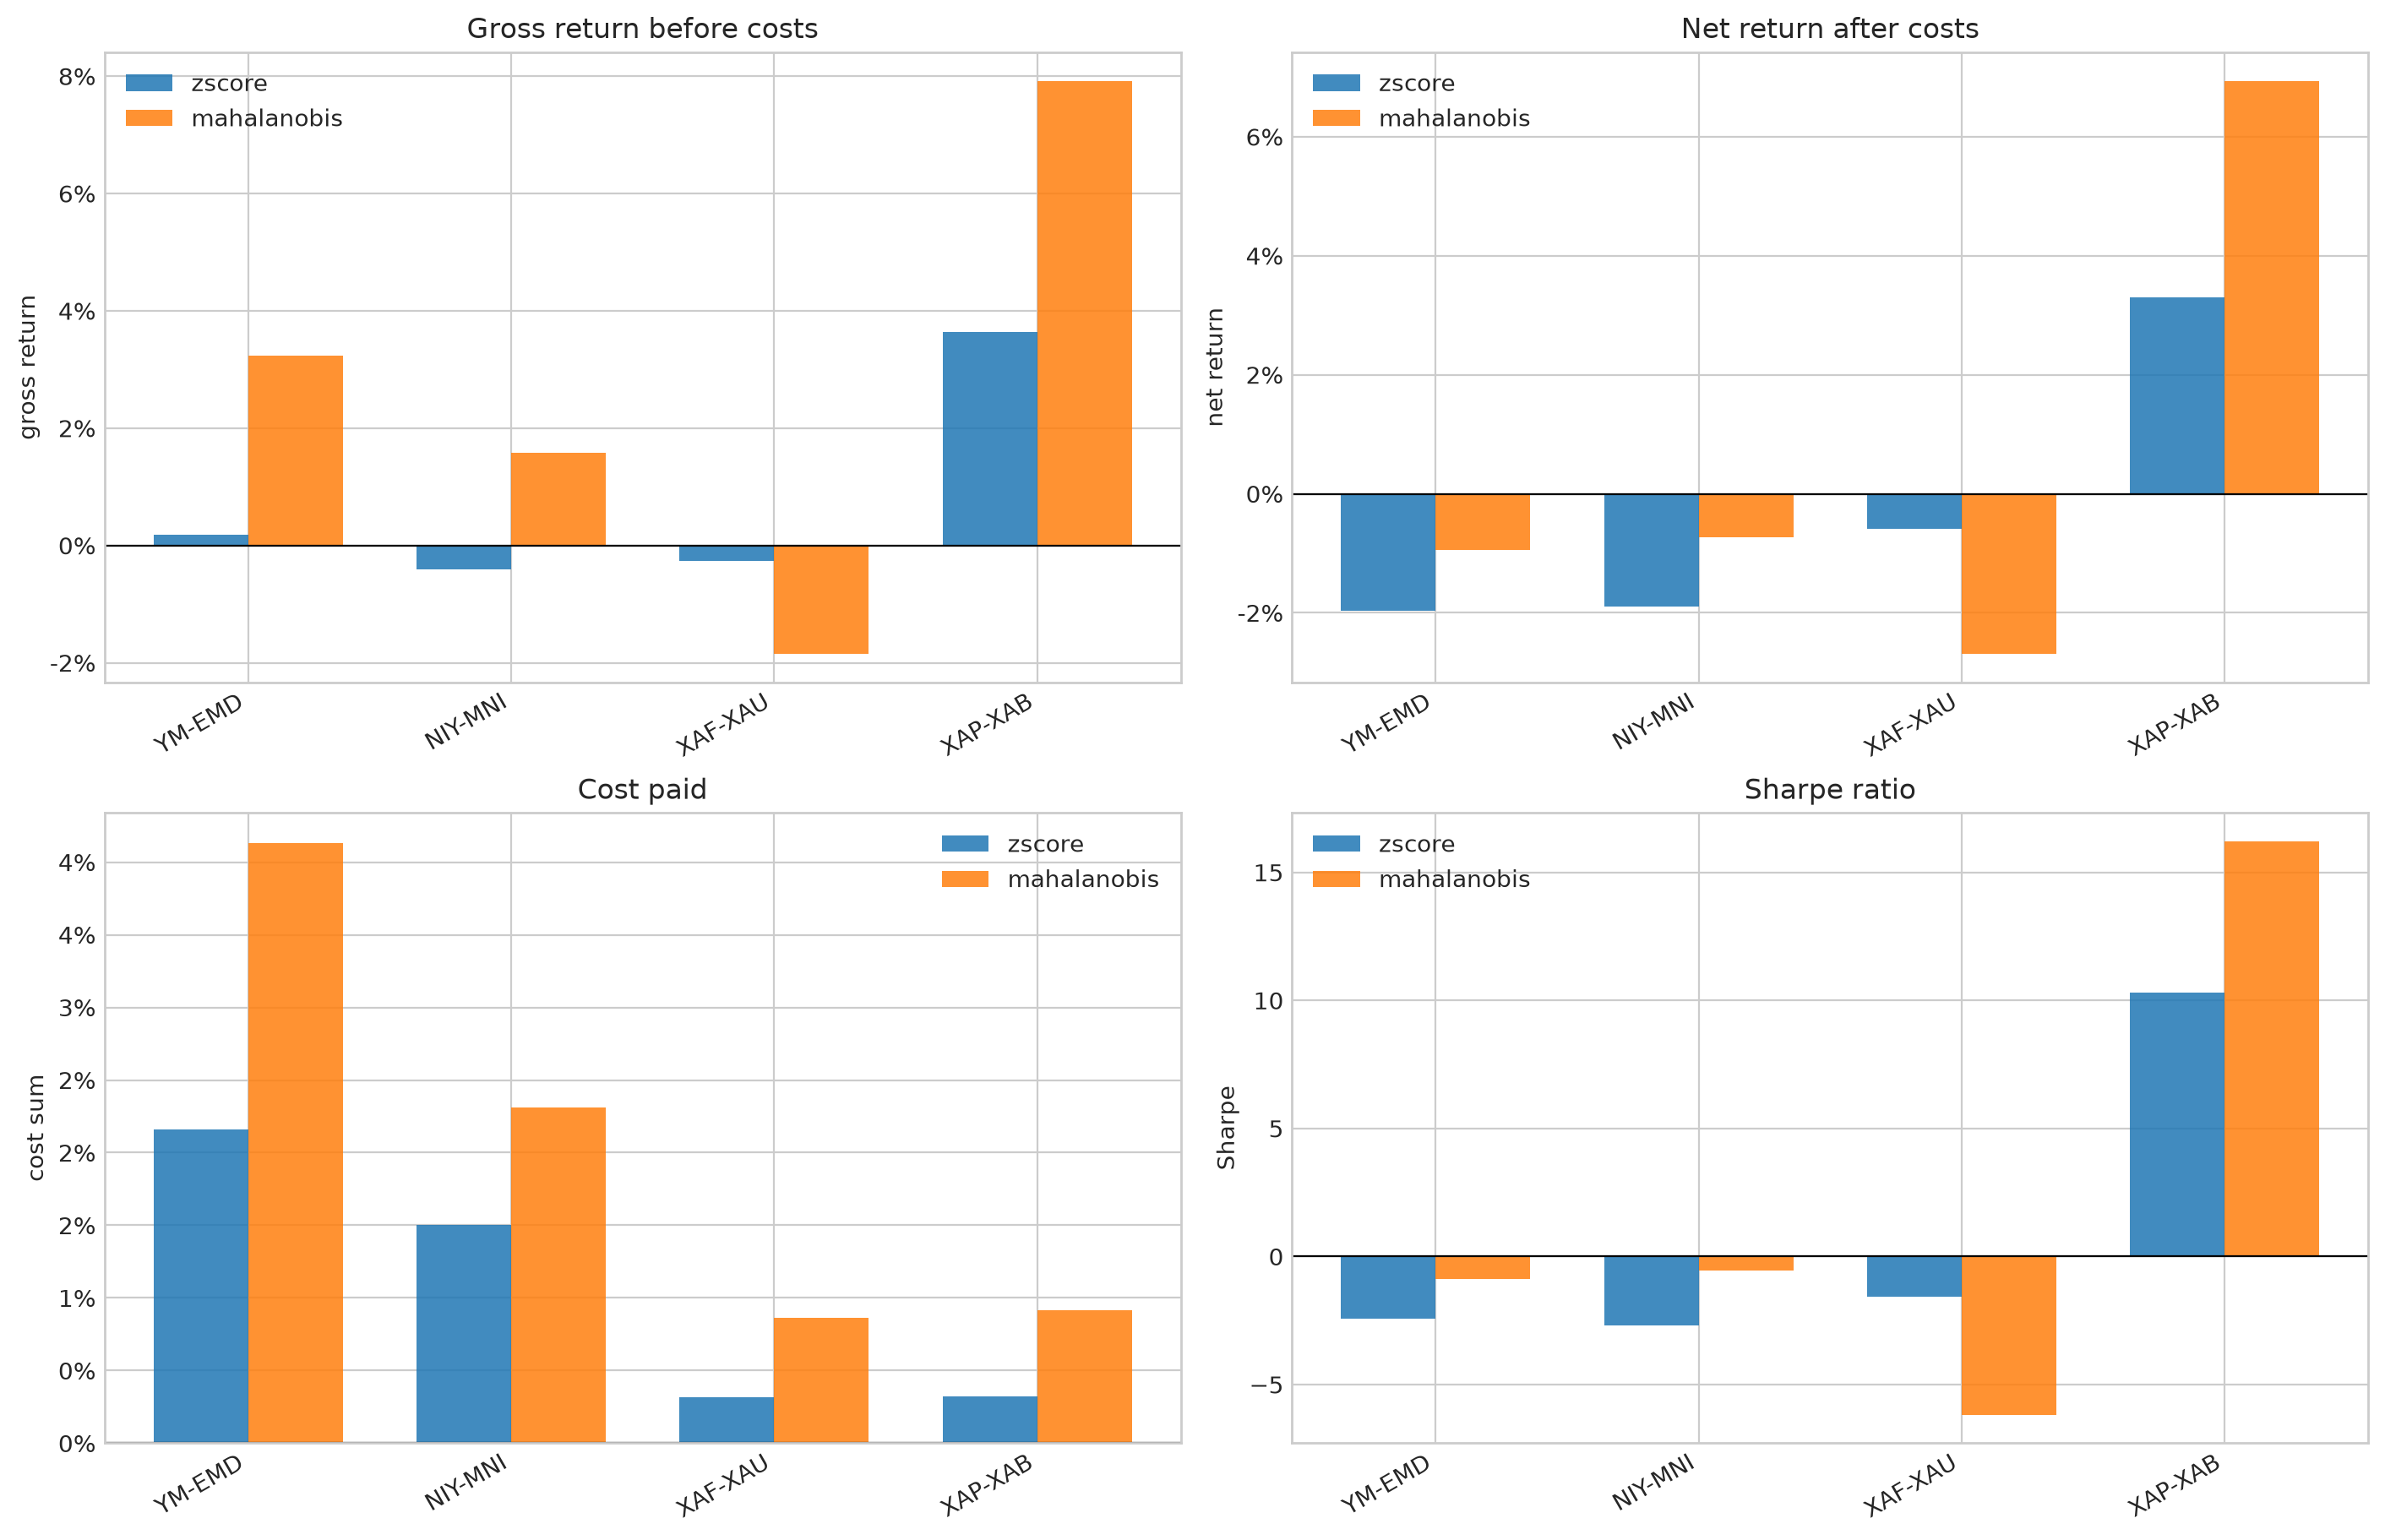

,pair,method,gross_compounded,cost_sum,net_compounded,sharpe_ratio,active_fraction,total_turnover,trades
0,NIY-MNI,mahalanobis,1.58%,2.31%,-0.74%,-0.55,18.9%,154.0,166
1,NIY-MNI,zscore,-0.41%,1.50%,-1.89%,-2.70,29.1%,100.0,93
2,XAF-XAU,mahalanobis,-1.85%,0.86%,-2.69%,-6.17,75.7%,57.4,70
3,XAF-XAU,zscore,-0.27%,0.32%,-0.59%,-1.56,47.7%,21.0,27
4,XAP-XAB,mahalanobis,7.92%,0.91%,6.94%,16.20,62.3%,60.9,69
5,XAP-XAB,zscore,3.64%,0.32%,3.30%,10.30,38.1%,21.5,28
6,YM-EMD,mahalanobis,3.24%,4.13%,-0.94%,-0.89,39.2%,275.5,331
7,YM-EMD,zscore,0.18%,2.16%,-1.96%,-2.41,43.3%,143.9,162


In [3]:
def compound_return(values: pd.Series) -> float:
    return float((1.0 + values.fillna(0.0)).prod() - 1.0)


summary_rows = []
for (pair, method), group in pair_returns.groupby(["pair", "method"], sort=True):
    summary_rows.append(
        {
            "pair": pair,
            "method": method,
            "gross_compounded": compound_return(group["gross_return"]),
            "net_compounded": compound_return(group["pair_return"]),
            "cost_sum": float(group["cost"].sum()),
            "active_fraction": float(group["active"].mean()),
            "total_turnover": float(group["turnover"].sum()),
            "trades": int((group["turnover"] > 0).sum()),
        }
    )
pair_summary = pd.DataFrame(summary_rows).merge(
    metrics.loc[:, ["pair", "method", "sharpe_ratio", "max_drawdown"]],
    on=["pair", "method"],
    how="left",
)


def grouped_bar(
    ax, table: pd.DataFrame, value_col: str, title: str, ylabel: str, percent: bool = False
) -> None:
    pairs = selected["pair"].tolist()
    x = np.arange(len(pairs))
    width = 0.36
    for offset, method in zip([-width / 2, width / 2], METHOD_ORDER, strict=True):
        values = [
            float(
                table.loc[(table["pair"] == pair) & (table["method"] == method), value_col].iloc[0]
            )
            for pair in pairs
        ]
        ax.bar(
            x + offset, values, width=width, label=method, color=METHOD_COLORS[method], alpha=0.85
        )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs, rotation=30, ha="right")
    if percent:
        ax.yaxis.set_major_formatter(pct)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
grouped_bar(
    axes[0, 0],
    pair_summary,
    "gross_compounded",
    "Gross return before costs",
    "gross return",
    percent=True,
)
grouped_bar(
    axes[0, 1], pair_summary, "net_compounded", "Net return after costs", "net return", percent=True
)
grouped_bar(axes[1, 0], pair_summary, "cost_sum", "Cost paid", "cost sum", percent=True)
grouped_bar(axes[1, 1], pair_summary, "sharpe_ratio", "Sharpe ratio", "Sharpe")
plt.show()

display(
    pair_summary.sort_values(["pair", "method"])
    .loc[
        :,
        [
            "pair",
            "method",
            "gross_compounded",
            "cost_sum",
            "net_compounded",
            "sharpe_ratio",
            "active_fraction",
            "total_turnover",
            "trades",
        ],
    ]
    .style.format(
        {
            "gross_compounded": "{:.2%}",
            "cost_sum": "{:.2%}",
            "net_compounded": "{:.2%}",
            "sharpe_ratio": "{:.2f}",
            "active_fraction": "{:.1%}",
            "total_turnover": "{:.1f}",
        }
    )
)

## Portfolio comparison

This is the experiment-level view across all selected pairs. It helps distinguish a pair-specific result from a portfolio-wide result.

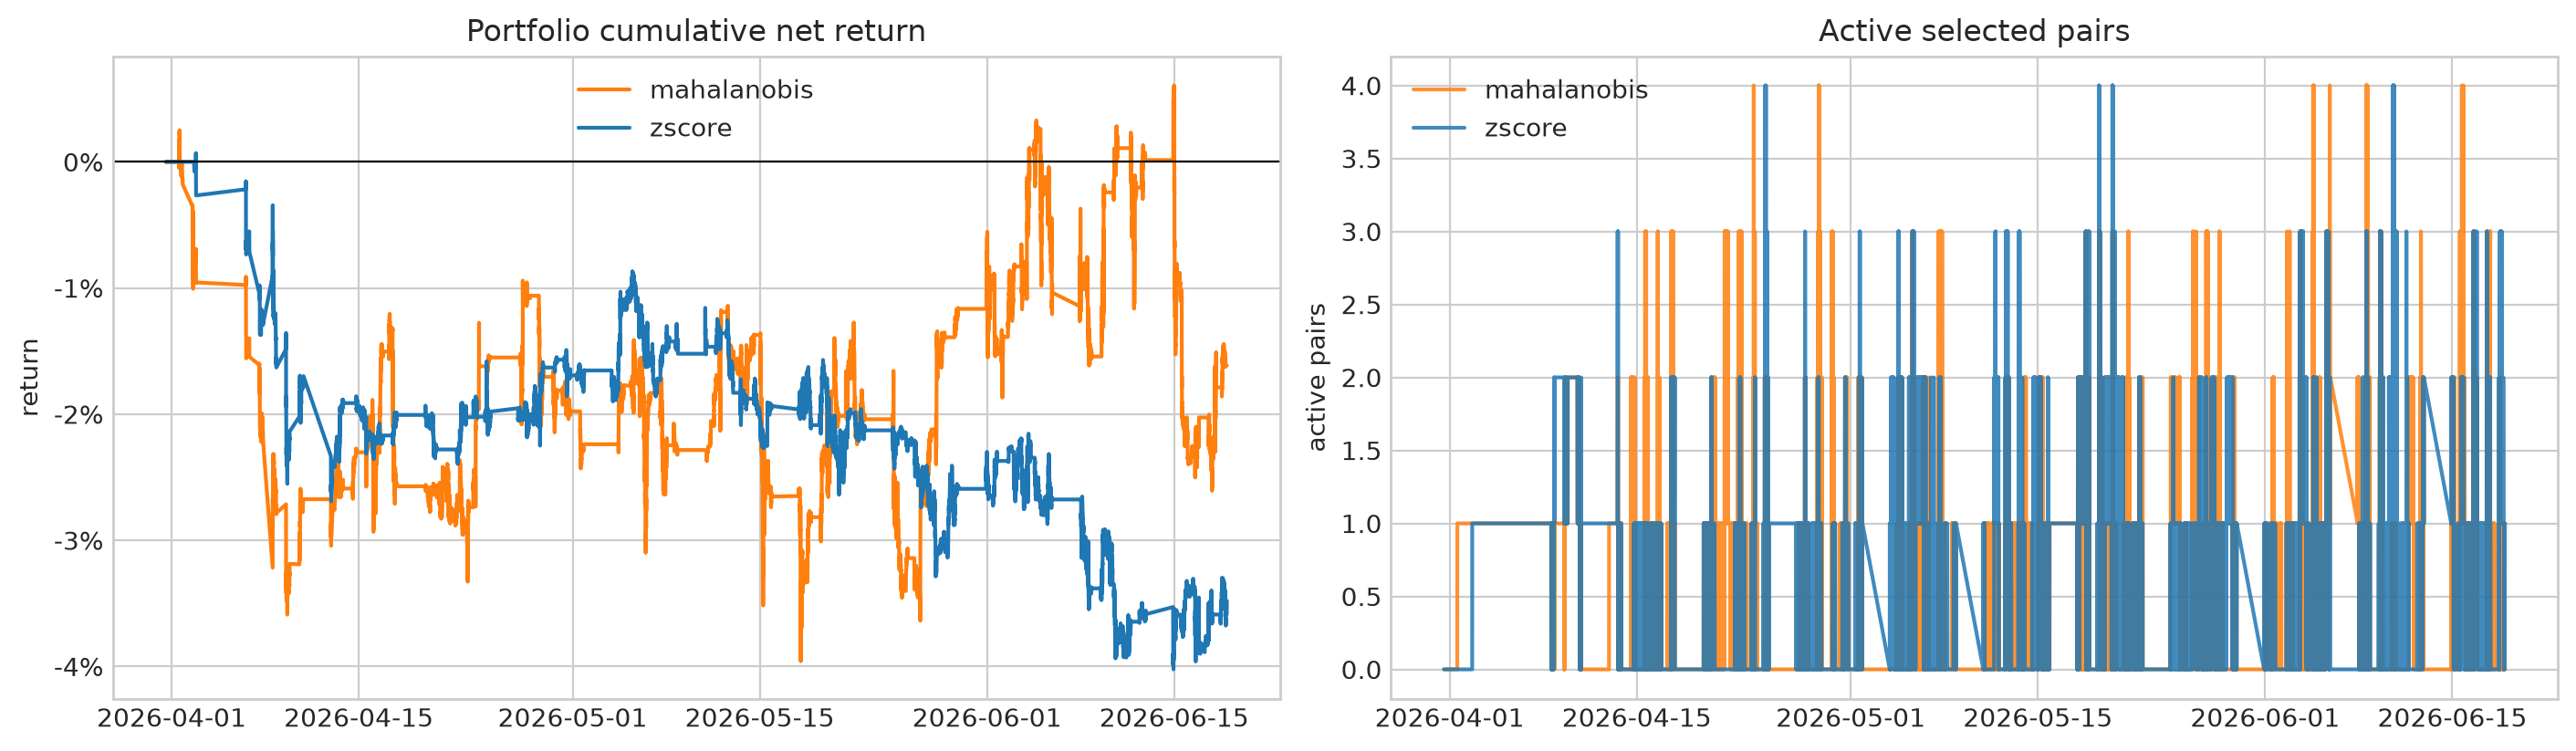

In [4]:
portfolio_plot = portfolio_returns.copy()
portfolio_plot["cum_net"] = portfolio_plot.groupby("method")["portfolio_return"].transform(
    lambda s: (1.0 + s.fillna(0.0)).cumprod() - 1.0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for method, group in portfolio_plot.groupby("method"):
    method_frame = group.sort_values("ts")
    axes[0].plot(
        method_frame["ts"],
        method_frame["cum_net"],
        label=method,
        color=METHOD_COLORS.get(method),
    )
    axes[1].plot(
        method_frame["ts"],
        method_frame["active_pairs"],
        label=method,
        color=METHOD_COLORS.get(method),
        alpha=0.85,
    )

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Portfolio cumulative net return")
axes[0].set_ylabel("return")
axes[0].yaxis.set_major_formatter(pct)
axes[0].legend()

axes[1].set_title("Active selected pairs")
axes[1].set_ylabel("active pairs")
axes[1].legend()
plt.show()

## Pair setup

The next sections focus on one pair. Change `PAIR` in the setup cell and rerun from here to inspect another selected pair.

In [5]:
def pair_selection_row(pair: str) -> pd.Series:
    rows = selected.loc[selected["pair"] == pair]
    if rows.empty:
        raise ValueError(f"{pair} is not in selected pairs: {selected['pair'].tolist()}")
    return rows.iloc[0]


def load_pair_frame(pair: str) -> pd.DataFrame:
    row = pair_selection_row(pair)
    root_a = row["root_a"]
    root_b = row["root_b"]
    left = pd.read_parquet(
        DATA_DIR / f"{root_a}.parquet",
        columns=["ts", "cont_logprice", "cont_logret", "cont_close", "volume"],
    ).rename(
        columns={
            "cont_logprice": "log_price_a",
            "cont_logret": "log_return_a",
            "cont_close": "close_a",
            "volume": "volume_a",
        }
    )
    right = pd.read_parquet(
        DATA_DIR / f"{root_b}.parquet",
        columns=["ts", "cont_logprice", "cont_logret", "cont_close", "volume"],
    ).rename(
        columns={
            "cont_logprice": "log_price_b",
            "cont_logret": "log_return_b",
            "cont_close": "close_b",
            "volume": "volume_b",
        }
    )
    frame = left.merge(right, on="ts", how="inner").sort_values("ts").reset_index(drop=True)
    frame["ts"] = pd.to_datetime(frame["ts"], utc=True)
    frame["spread"] = frame["log_price_b"] - float(row["hedge_ratio"]) * frame["log_price_a"]
    frame["train"] = np.arange(len(frame)) < int(row["test_start_index"])
    return frame


row = pair_selection_row(PAIR)
pair_frame = load_pair_frame(PAIR)
pair_method_returns = pair_returns.loc[pair_returns["pair"] == PAIR].copy()
test_start_index = int(row["test_start_index"])
test_start_ts = pair_frame.loc[test_start_index, "ts"]

pair_info = {
    "pair": PAIR,
    "root_a": row["root_a"],
    "root_b": row["root_b"],
    "asset_class": row["asset_class"],
    "full_start": pair_frame["ts"].min(),
    "full_end": pair_frame["ts"].max(),
    "test_start": test_start_ts,
    "observations": len(pair_frame),
    "test_observations": len(pair_frame) - test_start_index,
    "hedge_ratio": float(row["hedge_ratio"]),
}
display(pd.Series(pair_info, name="value"))

pair                                   XAP-XAB
root_a                                     XAP
root_b                                     XAB
asset_class                        SectorIndex
full_start           2026-01-02 14:30:00+00:00
full_end             2026-06-18 19:59:00+00:00
test_start           2026-04-08 14:02:00+00:00
observations                             10030
test_observations                         4012
hedge_ratio                           0.883636
Name: value, dtype: object

## Prices and hedge spread

This plot shows whether the selected pair was a broad co-movement story, a stationary spread story, or a fragile training-window artifact.

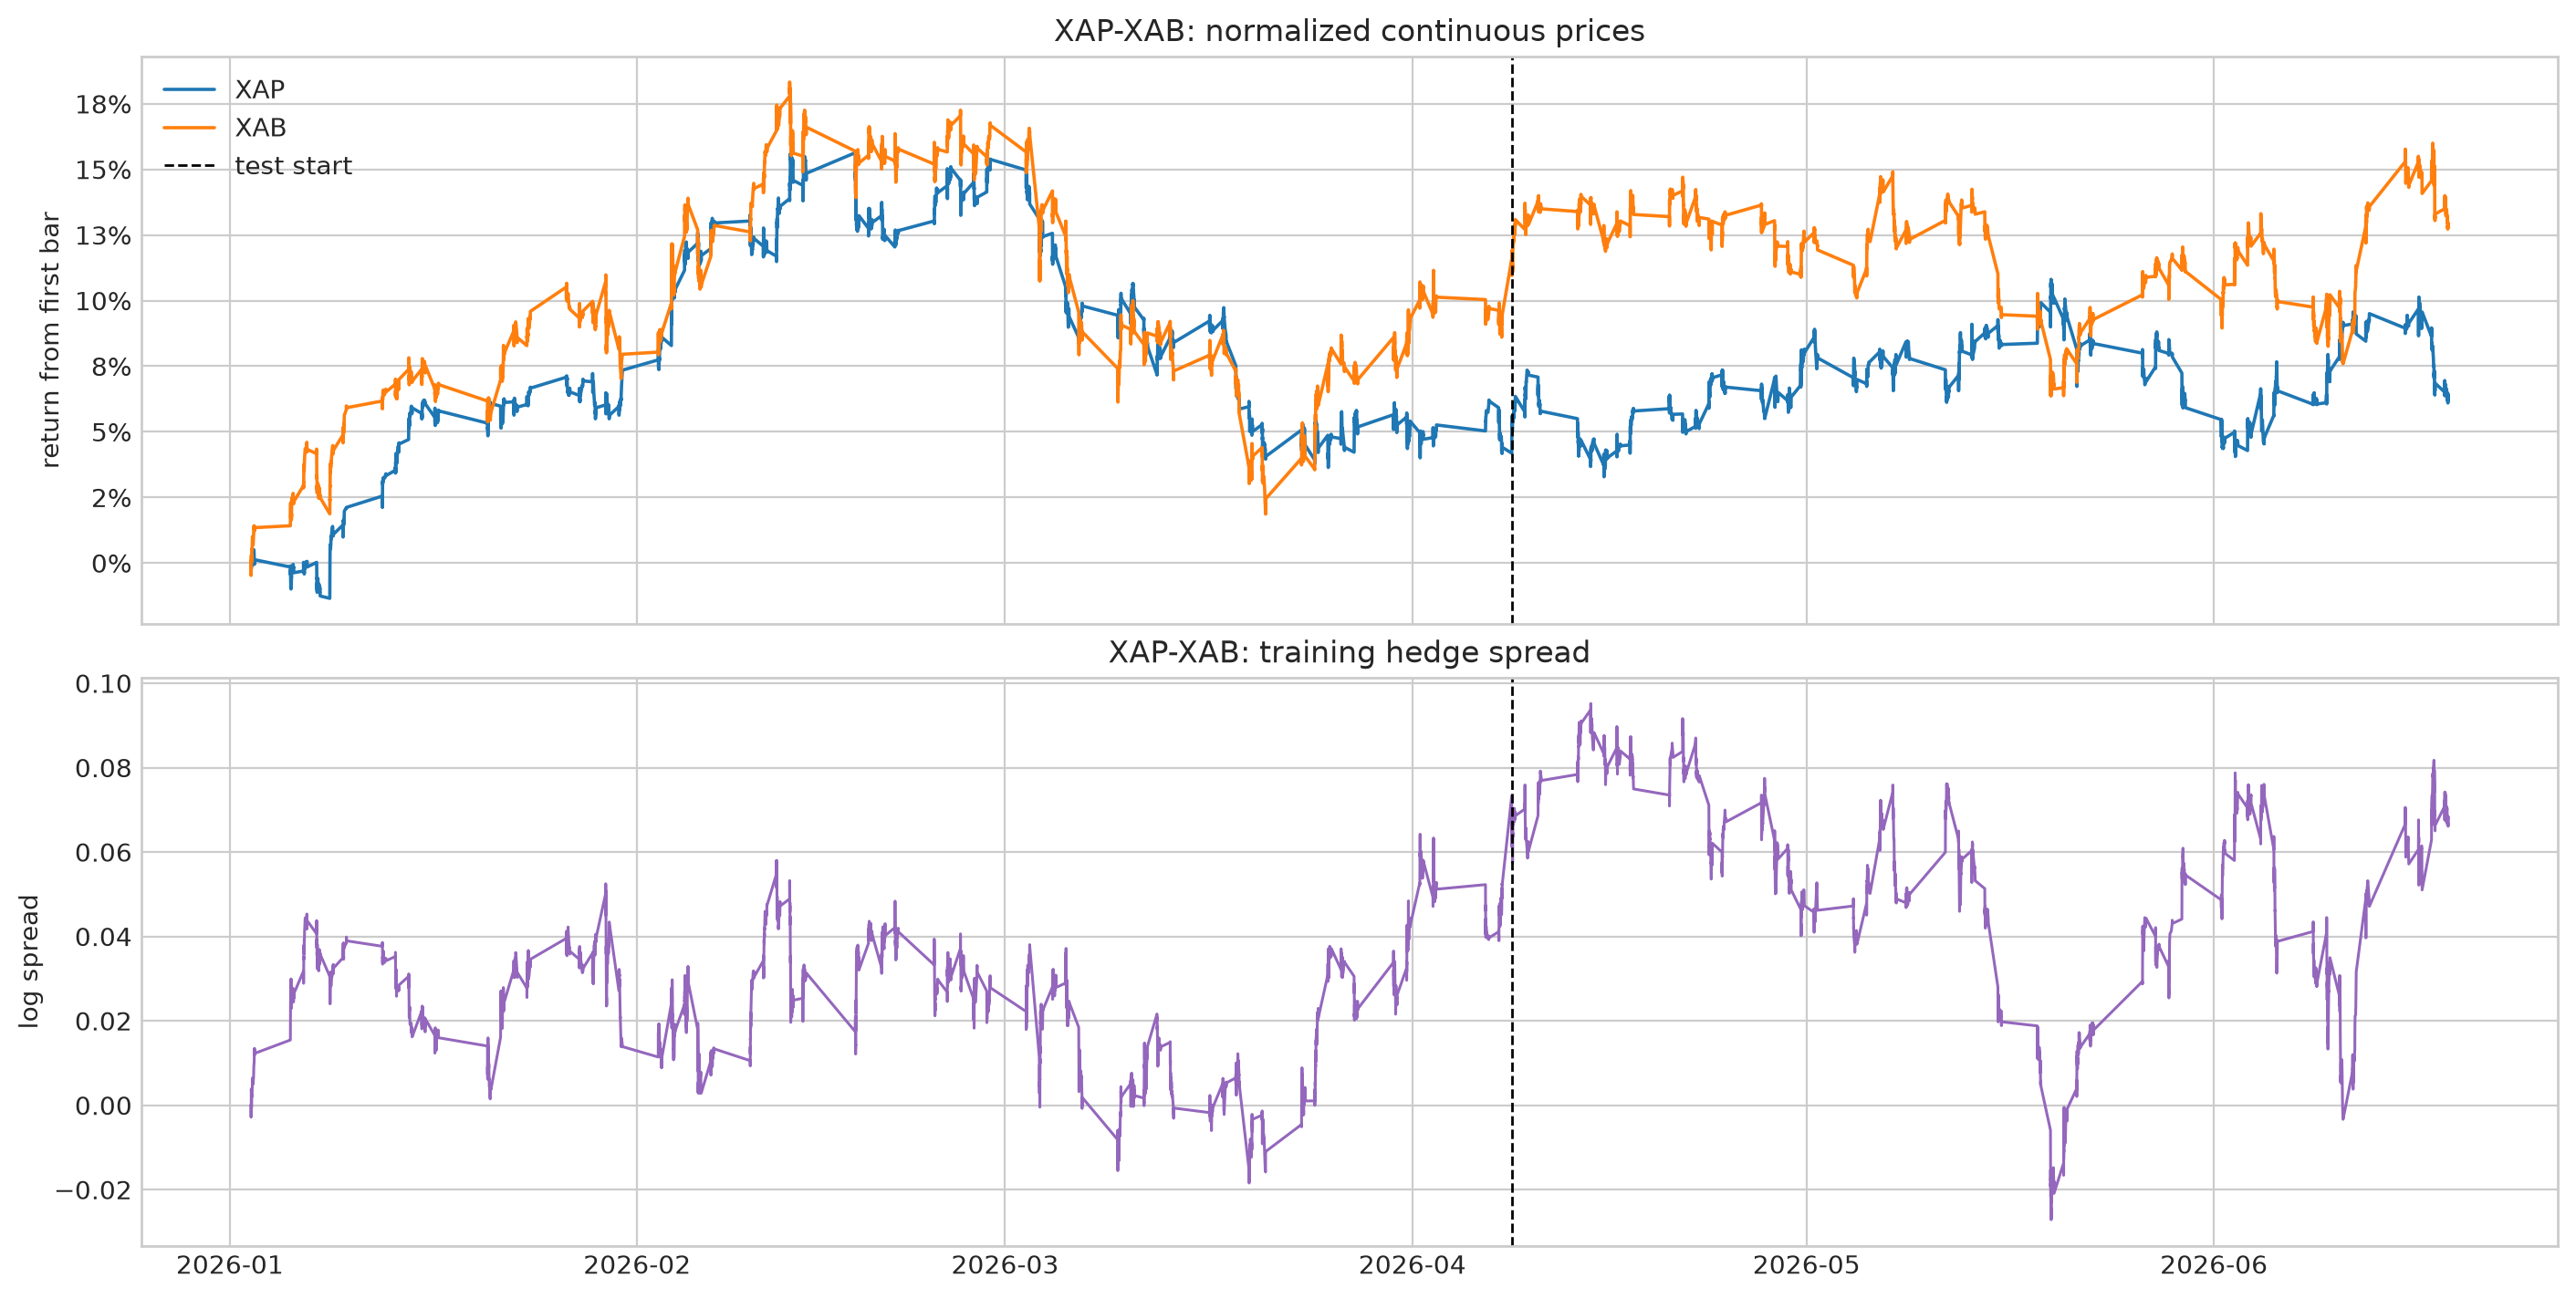

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

norm_a = pair_frame["close_a"] / pair_frame["close_a"].iloc[0] - 1.0
norm_b = pair_frame["close_b"] / pair_frame["close_b"].iloc[0] - 1.0
axes[0].plot(pair_frame["ts"], norm_a, label=str(row["root_a"]), linewidth=1.3)
axes[0].plot(pair_frame["ts"], norm_b, label=str(row["root_b"]), linewidth=1.3)
axes[0].axvline(test_start_ts, color="black", linestyle="--", linewidth=1.0, label="test start")
axes[0].set_title(f"{PAIR}: normalized continuous prices")
axes[0].set_ylabel("return from first bar")
axes[0].yaxis.set_major_formatter(pct)
axes[0].legend()

axes[1].plot(pair_frame["ts"], pair_frame["spread"], color="tab:purple", linewidth=1.1)
axes[1].axvline(test_start_ts, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title(f"{PAIR}: training hedge spread")
axes[1].set_ylabel("log spread")
plt.show()

## Indicator comparison

Z-score is a one-dimensional spread signal. Mahalanobis distance is a two-dimensional state-space signal that uses the rolling covariance of both assets. The shaded regions show when each method was active.

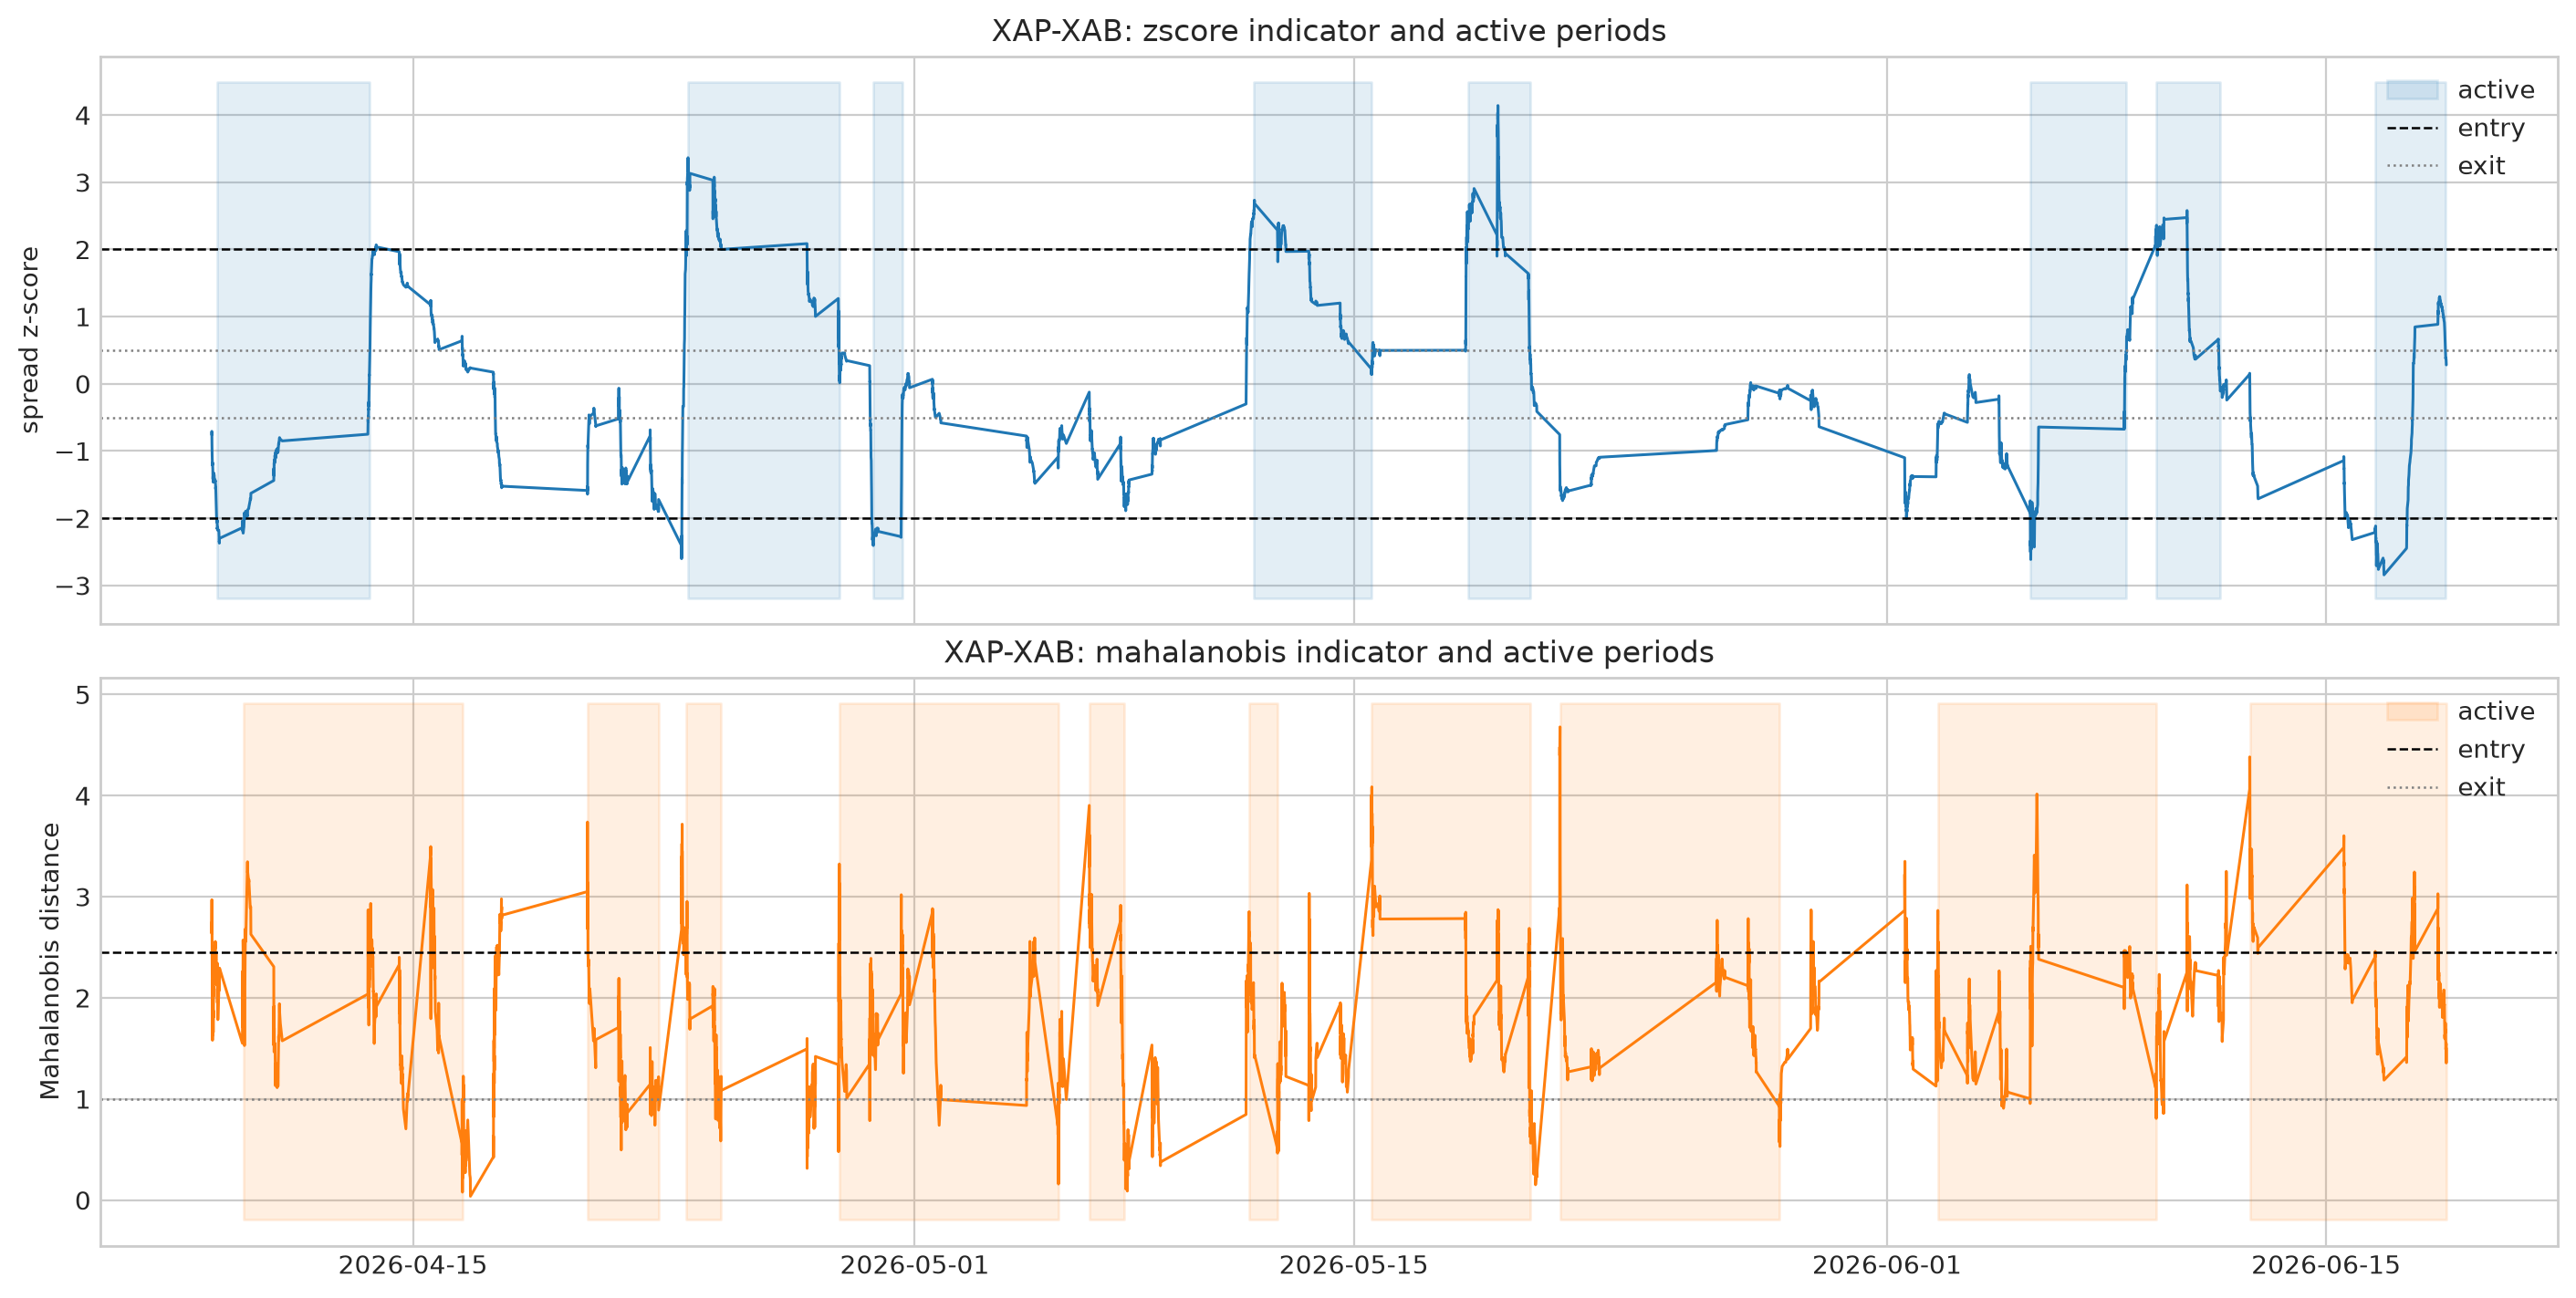

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

for ax, method in zip(axes, METHOD_ORDER, strict=True):
    method_frame = pair_method_returns.loc[pair_method_returns["method"] == method].sort_values(
        "ts"
    )
    ax.plot(
        method_frame["ts"], method_frame["indicator"], color=METHOD_COLORS[method], linewidth=1.1
    )
    y_min, y_max = ax.get_ylim()
    ax.fill_between(
        method_frame["ts"],
        y_min,
        y_max,
        where=method_frame["active"].astype(bool),
        color=METHOD_COLORS[method],
        alpha=0.12,
        label="active",
    )
    if method == "zscore":
        ax.axhline(Z_ENTRY, color="black", linestyle="--", linewidth=0.9, label="entry")
        ax.axhline(-Z_ENTRY, color="black", linestyle="--", linewidth=0.9)
        ax.axhline(Z_EXIT, color="gray", linestyle=":", linewidth=0.9, label="exit")
        ax.axhline(-Z_EXIT, color="gray", linestyle=":", linewidth=0.9)
        ax.set_ylabel("spread z-score")
    else:
        ax.axhline(MAHAL_ENTRY, color="black", linestyle="--", linewidth=0.9, label="entry")
        ax.axhline(MAHAL_EXIT, color="gray", linestyle=":", linewidth=0.9, label="exit")
        ax.set_ylabel("Mahalanobis distance")
    ax.set_title(f"{PAIR}: {method} indicator and active periods")
    ax.legend(loc="upper right")

plt.show()

## Position comparison

These plots reveal how differently the two methods express the same pair. Z-score generally produces a scalar spread trade. Mahalanobis can rotate position weights as the two-dimensional state changes.

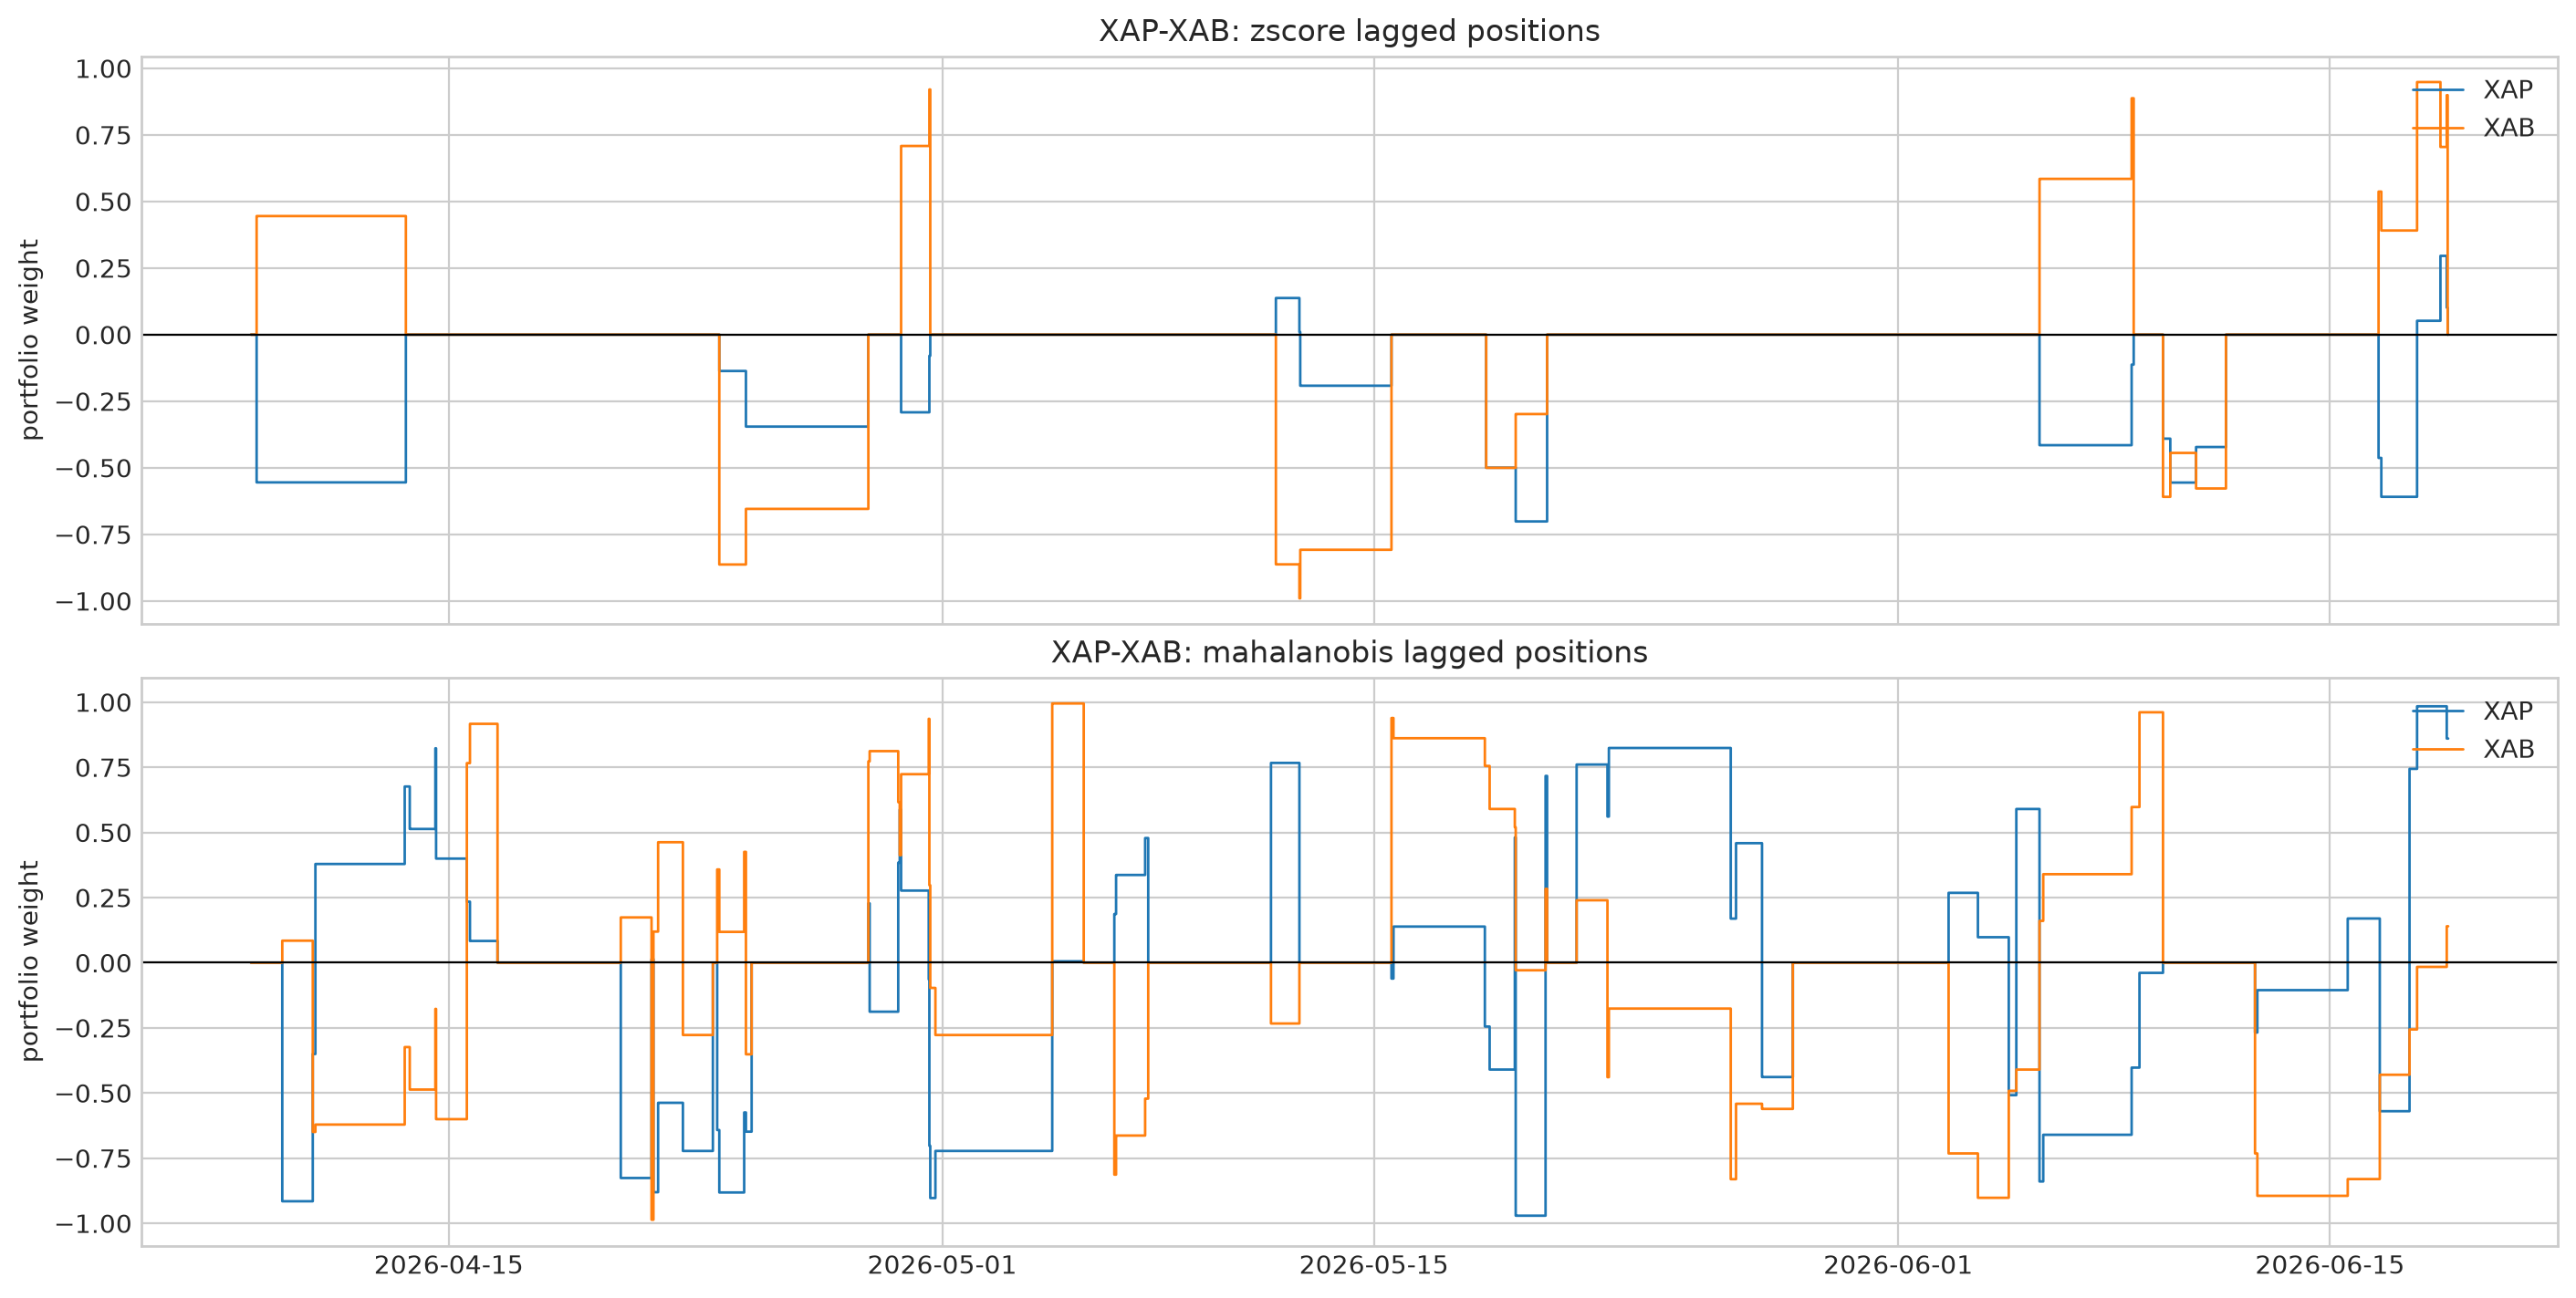

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

for ax, method in zip(axes, METHOD_ORDER, strict=True):
    method_frame = pair_method_returns.loc[pair_method_returns["method"] == method].sort_values(
        "ts"
    )
    ax.step(
        method_frame["ts"],
        method_frame["position_a"],
        where="post",
        label=str(row["root_a"]),
        linewidth=1.0,
    )
    ax.step(
        method_frame["ts"],
        method_frame["position_b"],
        where="post",
        label=str(row["root_b"]),
        linewidth=1.0,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{PAIR}: {method} lagged positions")
    ax.set_ylabel("portfolio weight")
    ax.legend(loc="upper right")

plt.show()

## Gross vs net P&L

This makes cost drag visible. If gross and net lines separate quickly, the signal may be real but not tradeable under the assumed cost model.

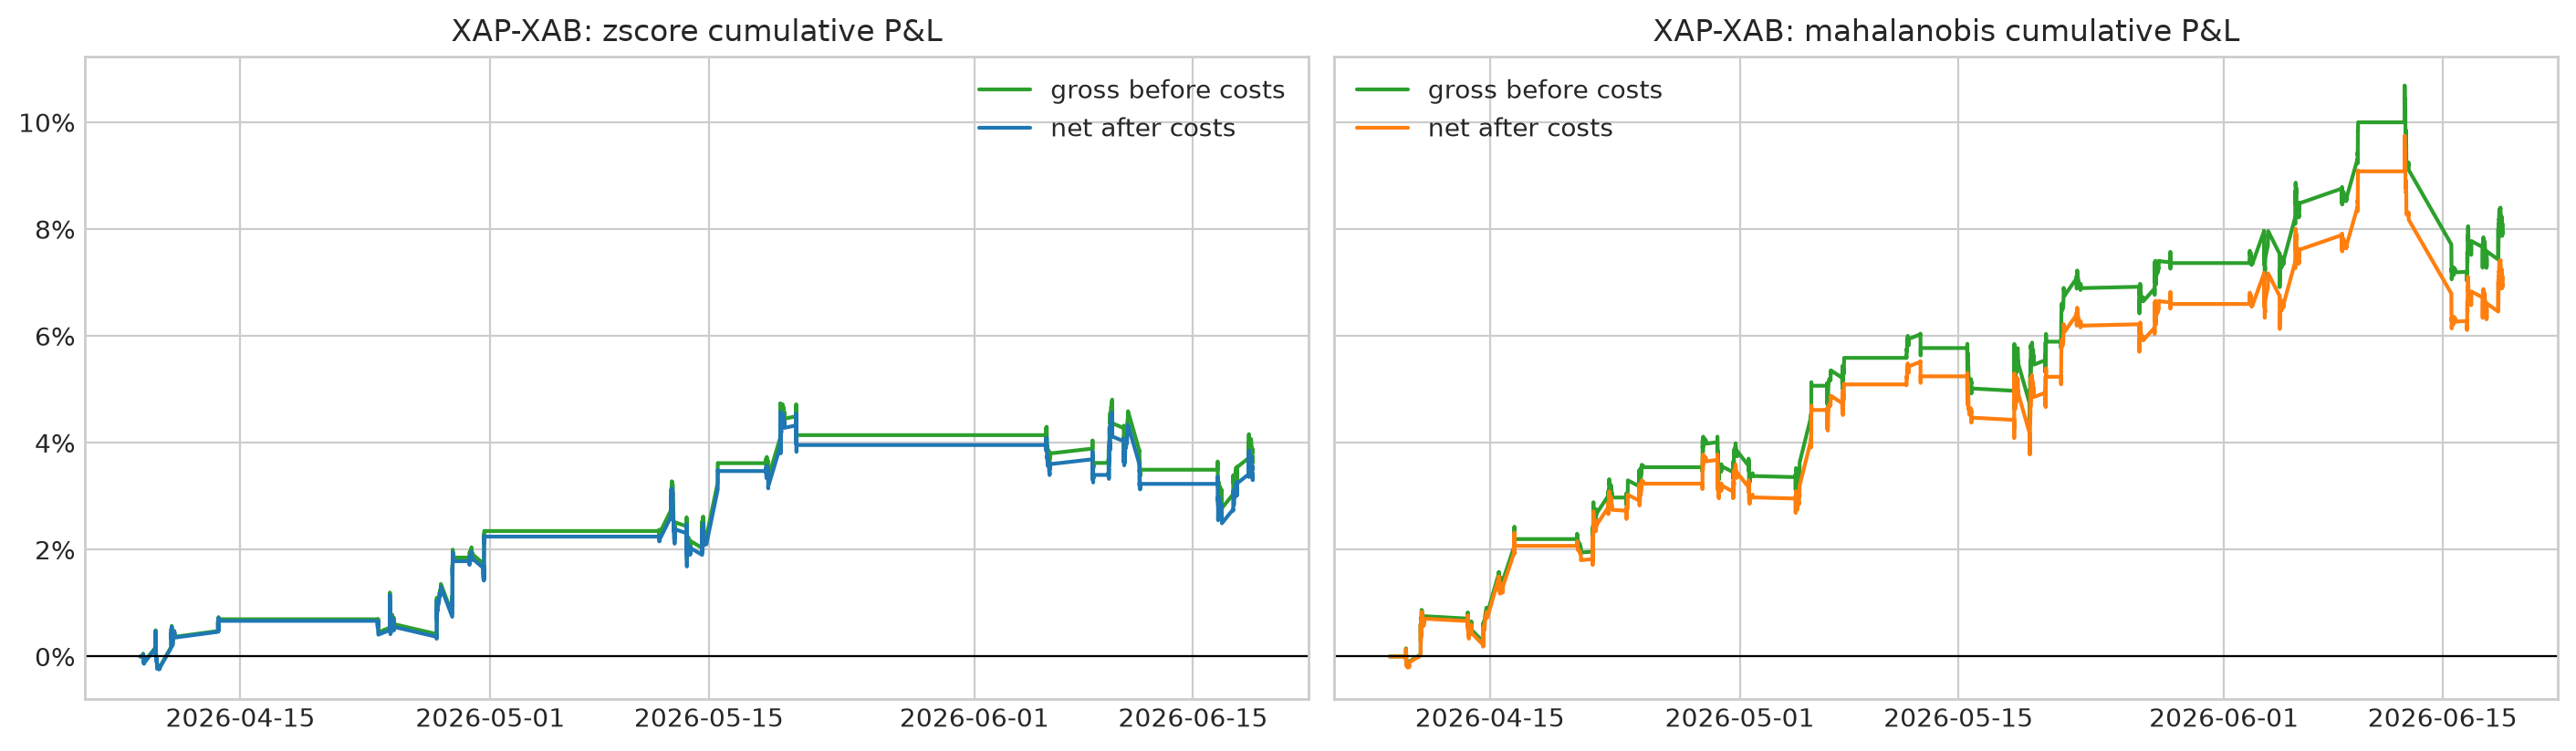

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, constrained_layout=True)

for ax, method in zip(axes, METHOD_ORDER, strict=True):
    method_frame = (
        pair_method_returns.loc[pair_method_returns["method"] == method].sort_values("ts").copy()
    )
    method_frame["cum_gross"] = (1.0 + method_frame["gross_return"].fillna(0.0)).cumprod() - 1.0
    method_frame["cum_net"] = (1.0 + method_frame["pair_return"].fillna(0.0)).cumprod() - 1.0
    ax.plot(
        method_frame["ts"], method_frame["cum_gross"], label="gross before costs", color="tab:green"
    )
    ax.plot(
        method_frame["ts"],
        method_frame["cum_net"],
        label="net after costs",
        color=METHOD_COLORS[method],
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{PAIR}: {method} cumulative P&L")
    ax.yaxis.set_major_formatter(pct)
    ax.legend()

plt.show()

## Active overlap

This shows whether the two methods were active at the same time. Non-overlap means the methods are exploiting different state definitions rather than simply trading the same moments.

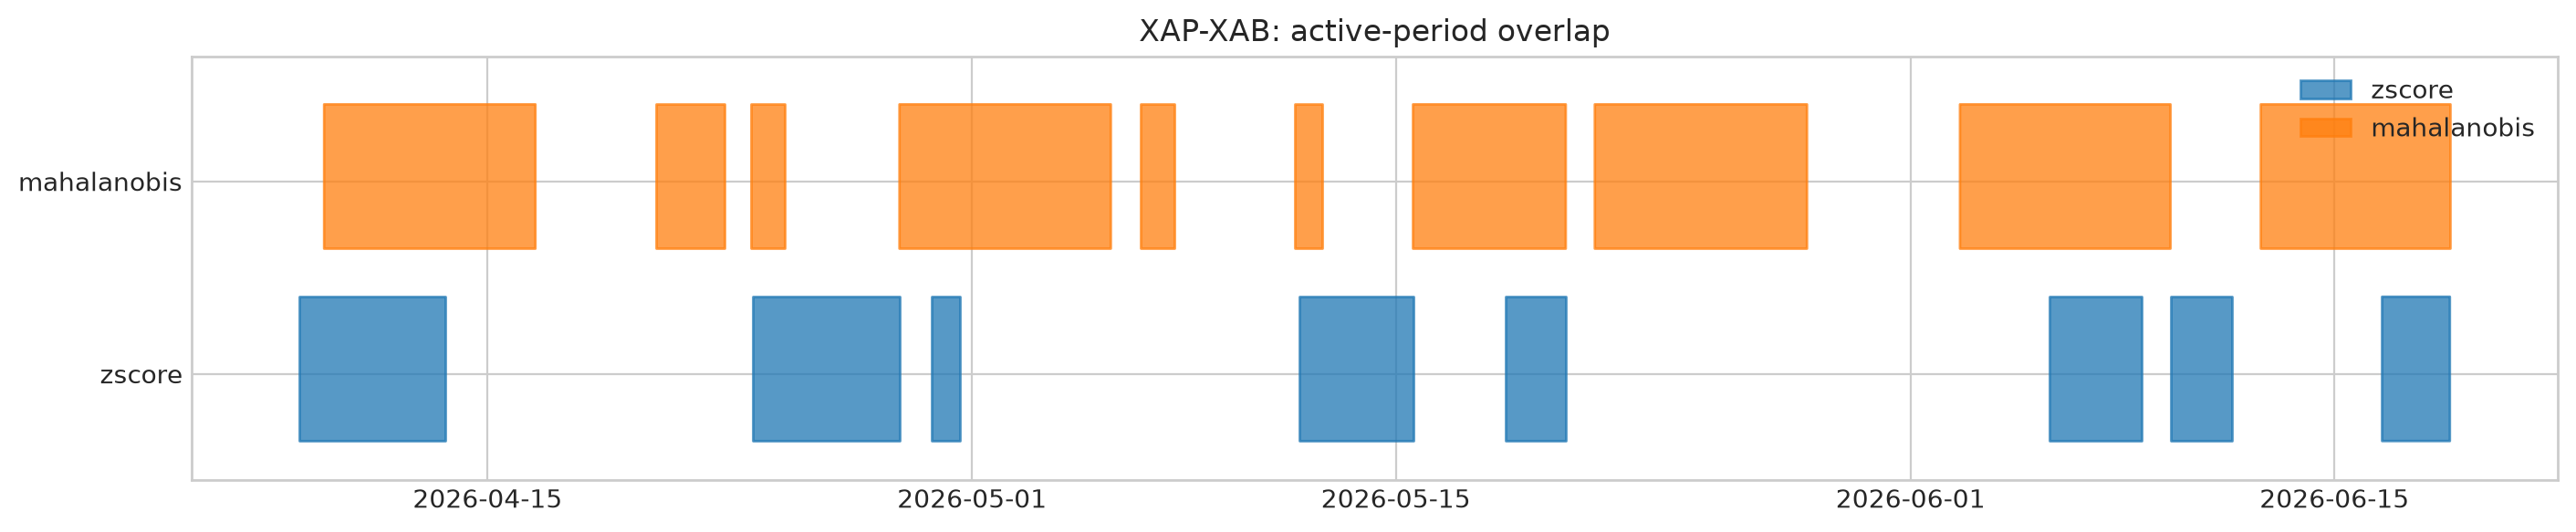

,value
zscore_active_fraction,38.1%
mahalanobis_active_fraction,62.3%
both_active_fraction,23.2%
either_active_fraction,77.2%


In [10]:
active = (
    pair_method_returns.pivot_table(index="ts", columns="method", values="active", aggfunc="max")
    .reindex(columns=METHOD_ORDER)
    .fillna(False)
    .astype(bool)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 2.8), constrained_layout=True)
for idx, method in enumerate(METHOD_ORDER):
    ax.fill_between(
        active.index,
        idx,
        idx + 0.75,
        where=active[method].to_numpy(dtype=bool),
        color=METHOD_COLORS[method],
        alpha=0.75,
        step="post",
        label=method,
    )
ax.set_yticks([0.35, 1.35])
ax.set_yticklabels(METHOD_ORDER)
ax.set_ylim(-0.2, 2.0)
ax.set_title(f"{PAIR}: active-period overlap")
ax.legend(loc="upper right")
plt.show()

overlap = pd.Series(
    {
        "zscore_active_fraction": float(active["zscore"].mean()),
        "mahalanobis_active_fraction": float(active["mahalanobis"].mean()),
        "both_active_fraction": float((active["zscore"] & active["mahalanobis"]).mean()),
        "either_active_fraction": float((active["zscore"] | active["mahalanobis"]).mean()),
    }
)
display(overlap.to_frame("value").style.format("{:.1%}"))

## Trade episodes

A single lucky episode is weaker evidence than repeated positive episodes. This view groups contiguous active bars into trade episodes and plots gross return before costs by episode.

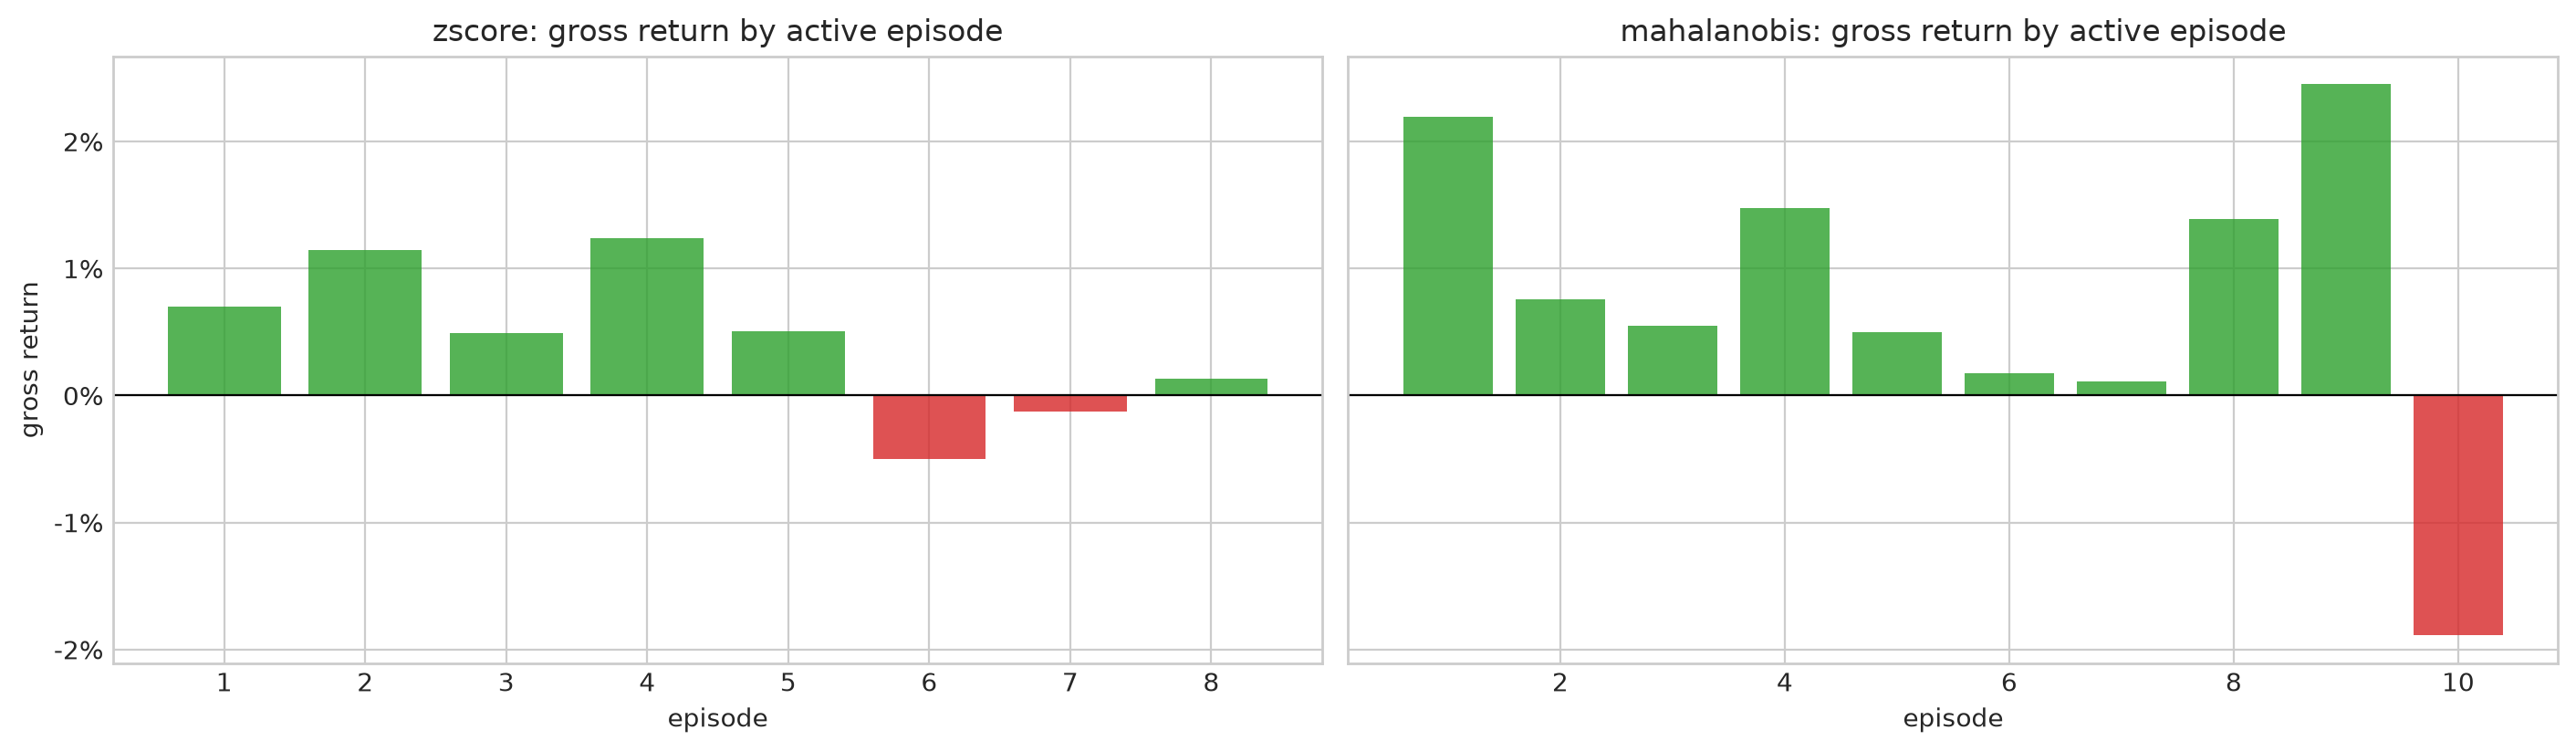

,episodes,positive_episodes,hit_rate,avg_gross,worst_gross,best_gross
method,,,,,,
zscore,8,6,75.0%,0.45%,-0.50%,1.24%
mahalanobis,10,9,90.0%,0.77%,-1.89%,2.45%


In [11]:
def summarize_episodes(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.sort_values("ts").copy()
    active_flag = frame["active"].astype(bool)
    episode_id = active_flag.ne(active_flag.shift(fill_value=False)).cumsum()
    rows = []
    for episode_number, (_, episode) in enumerate(
        frame.loc[active_flag].groupby(episode_id[active_flag]), start=1
    ):
        rows.append(
            {
                "episode": episode_number,
                "method": str(episode["method"].iloc[0]),
                "start": episode["ts"].iloc[0],
                "end": episode["ts"].iloc[-1],
                "bars": len(episode),
                "gross_compounded": compound_return(episode["gross_return"]),
                "net_compounded": compound_return(episode["pair_return"]),
                "cost_sum": float(episode["cost"].sum()),
                "avg_position_a": float(episode["position_a"].mean()),
                "avg_position_b": float(episode["position_b"].mean()),
            }
        )
    return pd.DataFrame(rows)


episodes = pd.concat(
    [summarize_episodes(group) for _, group in pair_method_returns.groupby("method")],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, constrained_layout=True)
for ax, method in zip(axes, METHOD_ORDER, strict=True):
    data = episodes.loc[episodes["method"] == method].copy()
    colors = np.where(data["gross_compounded"] >= 0, "tab:green", "tab:red")
    ax.bar(data["episode"], data["gross_compounded"], color=colors, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{method}: gross return by active episode")
    ax.set_xlabel("episode")
    ax.yaxis.set_major_formatter(pct)
axes[0].set_ylabel("gross return")
plt.show()

episode_summary = (
    episodes.groupby("method")
    .agg(
        episodes=("episode", "count"),
        positive_episodes=("gross_compounded", lambda s: int((s > 0).sum())),
        hit_rate=("gross_compounded", lambda s: float((s > 0).mean())),
        avg_gross=("gross_compounded", "mean"),
        worst_gross=("gross_compounded", "min"),
        best_gross=("gross_compounded", "max"),
    )
    .reindex(METHOD_ORDER)
)
display(
    episode_summary.style.format(
        {
            "hit_rate": "{:.1%}",
            "avg_gross": "{:.2%}",
            "worst_gross": "{:.2%}",
            "best_gross": "{:.2%}",
        }
    )
)

## Two-dimensional state view

This plot approximates the state-space distinction. The axes are rolling z-scores of each leg's continuous log price. Z-score trades a scalar spread; Mahalanobis uses the joint location relative to rolling covariance. Active points show where each method decided the state was tradeable.

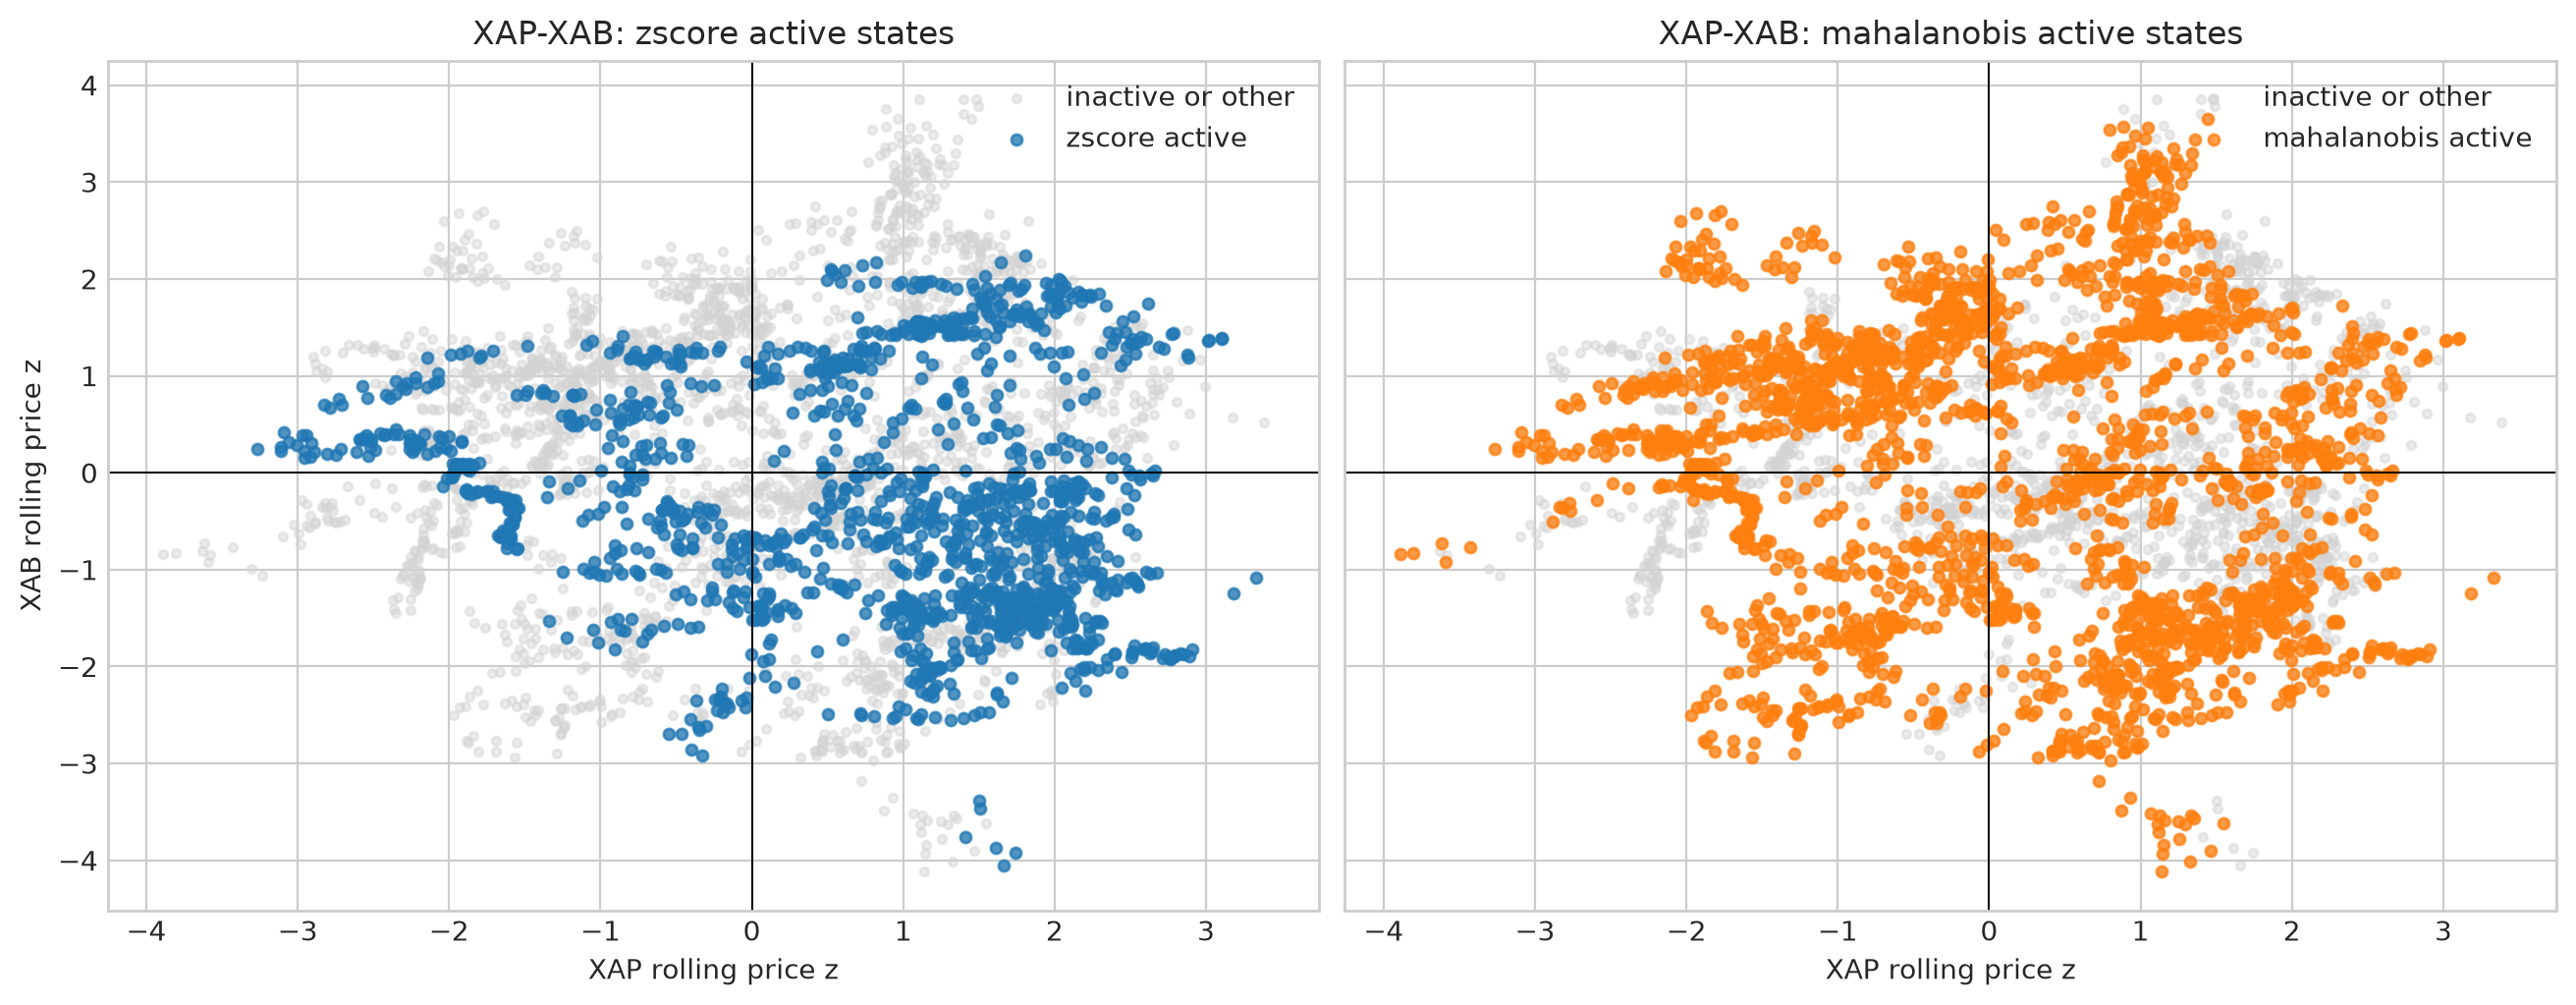

In [12]:
state = pair_frame.copy()
for side in ["a", "b"]:
    price_col = f"log_price_{side}"
    state[f"roll_z_{side}"] = (
        state[price_col] - state[price_col].rolling(LOOKBACK).mean()
    ) / state[price_col].rolling(LOOKBACK).std()
state = (
    state.iloc[test_start_index:]
    .loc[:, ["ts", "roll_z_a", "roll_z_b"]]
    .merge(active.reset_index(), on="ts", how="left")
)
state[METHOD_ORDER] = state[METHOD_ORDER].fillna(False).astype(bool)
state = state.dropna(subset=["roll_z_a", "roll_z_b"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, method in zip(axes, METHOD_ORDER, strict=True):
    ax.scatter(
        state["roll_z_a"],
        state["roll_z_b"],
        s=10,
        color="lightgray",
        alpha=0.45,
        label="inactive or other",
    )
    active_state = state.loc[state[method]]
    ax.scatter(
        active_state["roll_z_a"],
        active_state["roll_z_b"],
        s=16,
        color=METHOD_COLORS[method],
        alpha=0.75,
        label=f"{method} active",
    )
    ax.axhline(0, color="black", linewidth=0.7)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title(f"{PAIR}: {method} active states")
    ax.set_xlabel(f"{row['root_a']} rolling price z")
    ax.legend(loc="upper right")
axes[0].set_ylabel(f"{row['root_b']} rolling price z")
plt.show()

## What to look for

For a promising pair-method combination, the visual evidence should show:

- gross P&L that is not erased by costs;
- repeated positive episodes, not a single lucky interval;
- indicator excursions that line up with subsequent spread repair;
- stable enough pair behavior between the training and test windows;
- trade frequency and active time that are plausible for the contract liquidity.

For `XAP-XAB`, the distinguishing feature in this run is that both methods generated positive gross and net returns, while Mahalanobis found more active episodes and a higher gross return before costs.